## 1. Importing and Loading

In [1]:
### Importing Packages for Data Manuplation
import numpy as np
import pandas as pd

### Importing Packages for Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Packages for Data Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

### Importing Packages for Data Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Matplotlib is building the font cache; this may take a moment.


Loading the Dataset

In [2]:
data = pd.read_csv("tiktok_dataset.csv")

## 2(a). Exploratory Data Analysis

Inspecting the first five rows of the dataframe

In [3]:
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Getting some basic info such as shape, datatypes and Count of Non-null rows

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [5]:
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


From the above We can observe that there are some missing values in the columns claim_status, video_transcription_text, video_view_count, video_like_count, video_download_count, video_share_count, video_comment_count as the total count of not null values are less than total rows i.e., 19382 in the dataset and by looking at the 3rd quadrant values incomparision to the max values of the variables the huge gap among them in columns video_like_count, video_share_count, video_download_count, video_comment_count indicate potential outliers.

Let Solve Each issue individually starting with missing values

### Handling the Missing Values

In [6]:
# Check for the missing values
data.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [7]:
print('total before removal of missing  rows: ',data.shape[0])

print('total after removal of missing  rows: ',data.dropna(axis=0).shape[0])
print('Percentage of rows with missing values: ',(1-(data.dropna(axis=0).shape[0]/data.shape[0]))*100,'%' )

total before removal of missing  rows:  19382
total after removal of missing  rows:  19084
Percentage of rows with missing values:  1.5375090289959759 %


The proportion missing values out of total rows of data is less than 2% dropping the missing rows could be an appropriate method since the it does not effect total length of dataset significantly. 

In [8]:
# Drop rows with missing values
data = data.dropna(axis=0)

In [9]:
# check for duplicates
data.duplicated().sum()

np.int64(0)

It seems like there are no duplicates in the dataset

### Handling Outliers

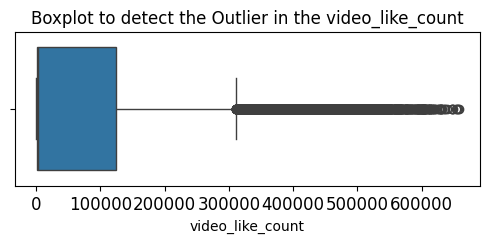

In [10]:
# Creating a box plot to identify the outliers
plt.figure(figsize=(6,2))
plt.title("Boxplot to detect the Outlier in the video_like_count", fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
sns.boxplot(x=data['video_like_count'])
plt.show()

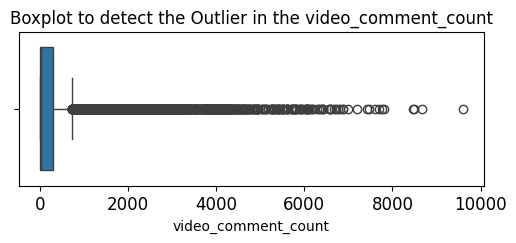

In [11]:
# Creating a box plot to identify the outliers
plt.figure(figsize=(6,2))
plt.title("Boxplot to detect the Outlier in the video_comment_count", fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
sns.boxplot(x=data['video_comment_count'])
plt.show()

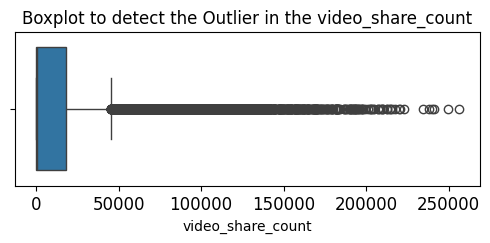

In [12]:
# Creating a box plot to identify the outliers
plt.figure(figsize=(6,2))
plt.title("Boxplot to detect the Outlier in the video_share_count", fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
sns.boxplot(x=data['video_share_count'])
plt.show()

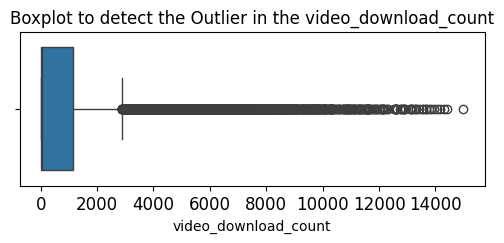

In [13]:
# Creating a box plot to identify the outliers
plt.figure(figsize=(6,2))
plt.title("Boxplot to detect the Outlier in the video_download_count", fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
sns.boxplot(x=data['video_download_count'])
plt.show()

all the above variables have extreme outliers and they could adversely effect the model performance let's strickly restrict the max values to upperlimit as deleting rows might not be an appropriate action to take as the outlier are not mere error or mistakes.

In [14]:
def outlier_imputer(column_list, iqr_factor):
    '''
    Impute upper-limit values in specified columns based on their interquartile range.

    Arguments:
        column_list: A list of columns to iterate over
        iqr_factor: A number representing x in the formula:
                    Q3 + (x * IQR). Used to determine maximum threshold,
                    beyond which a point is considered an outlier.

    The IQR is computed for each column in column_list and values exceeding
    the upper threshold for each column are imputed with the upper threshold value.
    '''
    for col in column_list:
        # Reassign minimum to zero
        data.loc[data[col] < 0, col] = 0

        # Calculate upper threshold
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        upper_threshold = q3 + (iqr_factor * iqr)
        print(col)
        print('q3:', q3)
        print('upper_threshold:', upper_threshold)

        # Reassign values > threshold to threshold
        data.loc[data[col] > upper_threshold, col] = upper_threshold
        print(data[col].describe())
        print()

In [15]:
outlier_imputer([ 'video_like_count', 'video_share_count',
       'video_download_count', 'video_comment_count'], 1.5)

video_like_count
q3: 125020.0
upper_threshold: 311333.875
count     19084.000000
mean      74323.538632
std      107103.555220
min           0.000000
25%         810.750000
50%        3403.500000
75%      125020.000000
max      311333.875000
Name: video_like_count, dtype: float64

video_share_count
q3: 18222.0
upper_threshold: 45382.5
count    19084.000000
mean     11246.910082
std      16573.533466
min          0.000000
25%        115.000000
50%        717.000000
75%      18222.000000
max      45382.500000
Name: video_share_count, dtype: float64

video_download_count
q3: 1156.25
upper_threshold: 2880.125
count    19084.000000
mean       713.444836
std       1049.881393
min          0.000000
25%          7.000000
50%         46.000000
75%       1156.250000
max       2880.125000
Name: video_download_count, dtype: float64

video_comment_count
q3: 292.0
upper_threshold: 728.5
count    19084.000000
mean       181.023501
std        272.084766
min          0.000000
25%          1.000000
50% 

let's check class balance of the target variable. The goal of project is to predict whether the user of a given post is verified or unverified.

In [16]:
# check class balance
data['verified_status'].value_counts(normalize=True)

verified_status
not verified    0.93712
verified        0.06288
Name: proportion, dtype: float64

Approximately 93.7% of the dataset represents videos posted by unverified accounts and 6.3% represents videos posted by verified accounts. So the outcome variable is not very balanced.

Using resampling to create class balance in the outcome variable.

In [17]:
# Using resampling to create class balance in the outcome variable

# identifing data points from majority and minority classes
data_majority = data[data["verified_status"] == "not verified"]
data_minority = data[data["verified_status"] == "verified"]

# Upsampling the minority class (which is "verified" in our case)
data_minority_upsampled = resample(data_minority,
                                   replace = True,                      # to sample with replacement
                                   n_samples=len(data_majority),        # to match majority class
                                   random_state=0)                      # to create reproducible results

# combine majority class with upsampled minority class
data_upsampled = pd.concat([data_majority, data_minority_upsampled]).reset_index(drop=True)

# Display new class counts
data_upsampled["verified_status"].value_counts()


verified_status
not verified    17884
verified        17884
Name: count, dtype: int64

Getting the average `video_transcription_text` length for videos posted by verified accounts and the average `video_transcription_text` length for videos posted by unverified accounts.

In [18]:
# To get lenth for video_transcription_text
data_upsampled[["verified_status","video_transcription_text"]].groupby(by="verified_status")[["video_transcription_text"]].agg(func = lambda array:np.mean([len(text) for text in array]))

,video_transcription_text
verified_status,
not verified,89.401141
verified,84.569559


Let's Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [19]:
# to Extract the length of each `video_transcription_text`
data_upsampled["text_length"] = data_upsampled['video_transcription_text'].apply(func = lambda text: len(text))

# Display the first few rows of dataframe after adding new column
data_upsampled.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts.

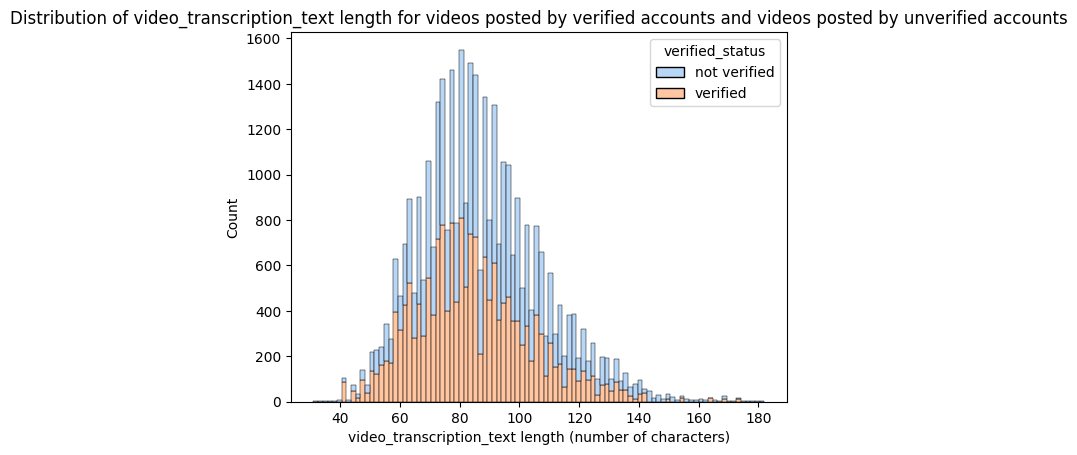

In [20]:
# Create two histograms in one plot
sns.histplot(data=data_upsampled, stat="count", multiple="stack", x="text_length", kde=False, palette="pastel",
             hue="verified_status", element="bars", legend=True)
plt.title("Distribution of video_transcription_text length for videos posted by verified accounts and videos posted by unverified accounts")
plt.xlabel("video_transcription_text length (number of characters)")
plt.ylabel("Count")
plt.show()

The distribution of `video_transcription_text` length is similar for verified and non-verified accounts. Most videos have transcription lengths between 60 and 110 characters, peaking around 80 characters. There is no substantial difference in text length across verification status, suggesting that transcription length alone may not be a distinguishing factor.

## 2(b). Examine correlations

In [21]:
# creating correlation matrix to help determine most correlated variables.
data_corr = data_upsampled[['video_duration_sec', 'video_view_count', 'video_like_count',
       'video_share_count', 'video_download_count', 'video_comment_count',
       'text_length']].corr(numeric_only=True)
data_corr

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
video_duration_sec,1.000000,0.013589,0.004494,0.001875,0.008972,-0.001086,-0.002981
video_view_count,0.013589,1.000000,0.856937,0.794957,0.782352,0.748361,0.244693
video_like_count,0.004494,0.856937,1.000000,0.888427,0.873458,0.818032,0.216693
video_share_count,0.001875,0.794957,0.888427,1.000000,0.803551,0.766203,0.208529
video_download_count,0.008972,0.782352,0.873458,0.803551,1.000000,0.911894,0.216871
video_comment_count,-0.001086,0.748361,0.818032,0.766203,0.911894,1.000000,0.217661
text_length,-0.002981,0.244693,0.216693,0.208529,0.216871,0.217661,1.000000


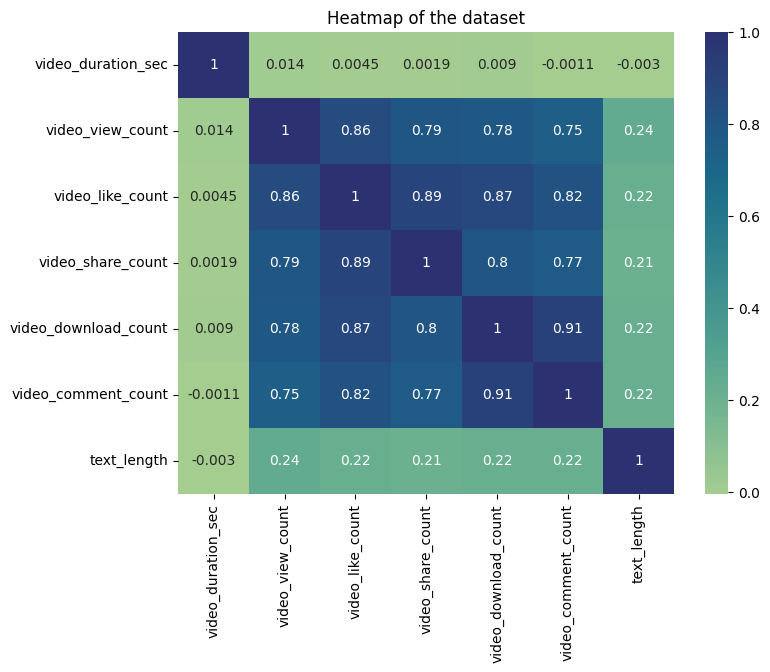

In [22]:
# Create a heatmap to visualize how correlated variables are
plt.figure(figsize=(8, 6))
sns.heatmap(
    data_upsampled[["video_duration_sec", "claim_status", "author_ban_status", "video_view_count", 
                    "video_like_count", "video_share_count", "video_download_count", "video_comment_count", "text_length"]]
    .corr(numeric_only=True),
    annot=True,
    cmap="crest")
plt.title("Heatmap of the dataset")
plt.show()

Based on the correlation matrix, there is strong evidence of multicollinearity among several independent variables, particularly within the engagement metrics: `video_view_count`, `video_like_count`, `video_share_count`, `video_download_count`, and `video_comment_count`. Correlations among these variables range from 0.75 to 0.91, which is well above common thresholds (e.g., 0.7 or 0.8) for concern. Including all of them in a logistic regression model would lead to unstable coefficient estimates, inflated standard errors, and difficulty in interpreting individual effects.

In contrast, `video_duration_sec` and `text_length` show very low correlations with each other and with the engagement metrics (all near zero), so they can be included without causing multicollinearity issues.

For model Building Included `video_duration_sec` and `text_length` as they are largely independent and may capture distinct aspects of video content.

Selected only one variable from the highly correlated engagement cluster to represent overall user interaction i.e., `video_view_count`

## 3(a). Select variables

Select the outcome variable.

In [23]:
# Select the outcome variable
y = data_upsampled["verified_status"]

Select the features.

In [29]:
#select features
X = data_upsampled[["video_duration_sec","claim_status","author_ban_status", "video_view_count","text_length"]]

# Display the first few rows of the features variable
X.head()

,video_duration_sec,claim_status,author_ban_status,video_view_count,text_length
0,59,claim,under review,343296.0,97
1,32,claim,active,140877.0,107
2,31,claim,active,902185.0,137
3,25,claim,active,437506.0,131
4,19,claim,active,56167.0,128


The `#` and `video_id` columns are not selected as features here, because they do not seem to be helpful for predicting whether a video presents a claim or an opinion. Also, `video_like_count`, `video_share_count`, `video_download_count`, and `video_comment_count` are not selected as a feature here, because it is strongly correlated with other features, as discussed earlier. And logistic regression has a no multicollinearity model assumption that needs to be met.

## 3(b). Train-test split

Split the data into training and testing sets.

In [30]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

Confirming that the dimensions of the training and testing sets are in alignment.

In [31]:
# Get the shape of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)        

X_train shape: (26826, 5)
X_test shape: (8942, 5)
y_train shape: (26826,)
y_test shape: (8942,)


## 3(c). Encode variables

Check the data types of the features.

In [32]:
# Check data types
X_train.dtypes

video_duration_sec      int64
claim_status           object
author_ban_status      object
video_view_count      float64
text_length             int64
dtype: object

In [33]:
# Get uniquue values in claim_status and author_ban_status columns
print("Unique values in claim_status column:", X_train["claim_status"].unique())
print("Unique values in author_ban_status column:", X_train["author_ban_status"].unique())

Unique values in claim_status column: ['opinion' 'claim']
Unique values in author_ban_status column: ['active' 'under review' 'banned']


As shown above, the `claim_status` and `author_ban_status` features are each of data type `object` currently. In order to work with the implementations of models through `sklearn`, these categorical features will need to be made numeric. One way to do this is through one-hot encoding.

Encode categoriacal features in the training set using an appropriate method.

In [35]:
# Select the training features that need to be one-hot encoded
X_train_to_encode = X_train[["claim_status", "author_ban_status"]]

# Display the first few rows of the features that need to be one-hot encoded
X_train_to_encode.head()

,claim_status,author_ban_status
33058,opinion,active
20491,opinion,active
25583,opinion,active
18474,opinion,active
27312,opinion,active


In [36]:
# Set up an encoder to one-hot encode the claim_status and author_ban_status columns
X_encoder = OneHotEncoder(drop="first", sparse_output=False)

In [37]:
# Fit and transform the training features that need to be one-hot encoded
X_train_encoded = X_encoder.fit_transform(X_train_to_encode)

In [38]:
# Get feature names for the one-hot encoded columns
X_encoder.get_feature_names_out()

array(['claim_status_opinion', 'author_ban_status_banned',
       'author_ban_status_under review'], dtype=object)

In [39]:
# Get the first few rows of the one-hot encoded features
X_train_encoded[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [40]:
# Place encoded features in a dataframe and display the first few rows
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=X_encoder.get_feature_names_out())
X_train_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [41]:
# Concatenate `X_train` and `X_train_encoded_df` to form the final dataframe for training data (`X_train_final`)
# Note: Using `.reset_index(drop=True)` to reset the index in X_train after dropping `claim_status` and `author_ban_status`,
# so that the indices align with those in `X_train_encoded_df` and `count_df`
X_train_final = pd.concat([X_train.drop(columns=["claim_status", "author_ban_status"]).reset_index(drop=True), 
                           X_train_encoded_df.reset_index(drop=True)], axis=1)
# Display the first few rows of the final dataframe for training data
X_train_final.head()

,video_duration_sec,video_view_count,text_length,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,33,2252.0,71,1.0,0.0,0.0
1,52,6664.0,109,1.0,0.0,0.0
2,37,6327.0,99,1.0,0.0,0.0
3,57,1702.0,80,1.0,0.0,0.0
4,21,3842.0,66,1.0,0.0,0.0


In [42]:
# Chech the data type of outcome variable
y_train.dtypes

dtype('O')

In [43]:
# Get the Unique values in the outcome variable
y_train.unique()

array(['verified', 'not verified'], dtype=object)

In [45]:
# Set up the one-hot encoder for the categorical outcome variable
y_encoder = OneHotEncoder(sparse_output=False, drop='first')
y_train_final = y_encoder.fit_transform(y_train.values.reshape(-1, 1)).ravel()
# Display the first few rows of the encoded outcome variable
y_train_final[:5]

array([1., 1., 1., 1., 1.])

## 3(d). Model Building

Contructing a model and fit it to the training set.

In [46]:
# Contracting the logistic regression model
log_clf = LogisticRegression(random_state=0, max_iter=800).fit(X_train_final, y_train_final)

## 4(a). Results and Evaluation

Evaluate the model

Encode categorial features in the testing set using an approprite method.

In [47]:
# selecting the testing features that need to be one-hot encoded
X_test_to_encode = X_test[["claim_status", "author_ban_status"]]

# Display the first few rows of the testing features that need to be one-hot encoded
X_test_to_encode.head()

,claim_status,author_ban_status
21061,opinion,active
31748,opinion,active
20197,claim,active
5727,claim,active
11607,opinion,active


In [48]:
# transform the testing features that need to be one-hot encoded using the encoder fitted on the training data
X_test_encoded = X_encoder.transform(X_test_to_encode)

In [49]:
# Place encoded features in a dataframe and display the first few rows
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=X_encoder.get_feature_names_out())

In [51]:
# Concatenate `X_test` and `X_test_encoded_df` to form the final dataframe for training data (`X_test_final`)
# Note: Using `.reset_index(drop=True)` to reset the index in X_test after dropping `claim_status`, and `author_ban_status`,
# so that the indices align with those in `X_test_encoded_df` and `test_count_df`

X_test_final = pd.concat([X_test.drop(columns=["claim_status", "author_ban_status"]).reset_index(drop=True),X_test_encoded_df.reset_index(drop=True)], axis=1)

X_test_final.head()

,video_duration_sec,video_view_count,text_length,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,41,2118.0,50,1.0,0.0,0.0
1,27,5701.0,78,1.0,0.0,0.0
2,31,449767.0,127,0.0,0.0,0.0
3,19,792813.0,105,0.0,0.0,0.0
4,54,2044.0,51,1.0,0.0,0.0


In [53]:
# Encode the testing outcome variable
# Notes:
#   - Adjusting the shape of `y_test` before passing into `.transform()`, since it takes in 2D array
#   - Using `.ravel()` to flatten the array returned by `.transform()`, so that it can be used later to compare with predictions
y_test_final = y_encoder.transform(y_test.values.reshape(-1,1)).ravel()

y_test_final[:5]

array([1., 1., 1., 0., 0.])

Test the logistic regression model. Use the model to make predictions on the encoded testing set.

In [54]:
#  Use the logistic regression model to make predictions on the testing data
y_pred = log_clf.predict(X_test_final)

# Display the  predictions for the first few rows of the testing data
y_pred[:5]

array([1., 1., 0., 0., 1.])

## 4(b). Visualize Model Results

Create a confusion matrix to visualize the results of the logistic regression model.

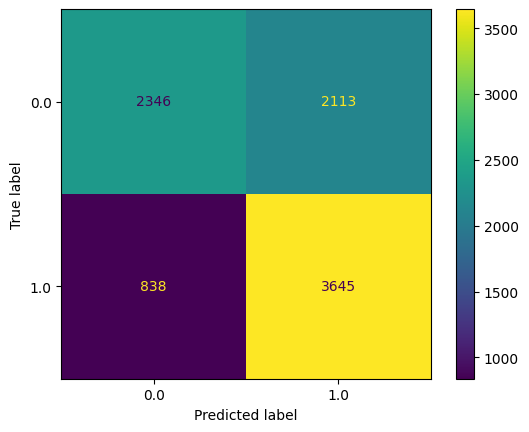

In [56]:
# Compute values for the confusion matrix
log_cm = confusion_matrix(y_test_final, y_pred, labels=log_clf.classes_)

# Create display for the confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=log_clf.classes_)

# plot the confusion matrix
log_disp.plot()

# Display plot
plt.show()

In [62]:
print('correlation matrix: ',log_cm )

correlation matrix:  [[2346 2113]
 [ 838 3645]]


In [57]:
accuracy = (log_cm[0][0] + log_cm[1][1]) / log_cm.sum()
print("Accuracy of the logistic regression model:", accuracy)

Accuracy of the logistic regression model: 0.6699843435473049


In [58]:
# Create classification report for logistic regression model
target_labels = ["verified", "not verified"]
print(classification_report(y_test_final, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

    verified       0.74      0.53      0.61      4459
not verified       0.63      0.81      0.71      4483

    accuracy                           0.67      8942
   macro avg       0.68      0.67      0.66      8942
weighted avg       0.68      0.67      0.66      8942



## 4(c). Interpret model coefficients

In [60]:
# Get the feature names from the model and the model coefficients (which represent log-odds ratios)
# Place into a DataFrame for readability
pd.DataFrame(data={"Feature Name":log_clf.feature_names_in_, "Model Coefficient":log_clf.coef_[0]})

,Feature Name,Model Coefficient
0,video_duration_sec,-5.973009e-03
1,video_view_count,-5.566854e-07
2,text_length,-8.287935e-03
3,claim_status_opinion,1.172747e+00
4,author_ban_status_banned,-1.863028e-01
5,author_ban_status_under review,-1.185875e-01


## 5. Conclusion

The logistic regression model achieves an overall accuracy of 67% on a balanced dataset, performing noticeably better at identifying "not verified" accounts (81% recall) than verified accounts (53% recall). While precision for verified predictions is relatively strong at 74%, the low recall means the model misses nearly half of all actual verified accounts, biasing predictions toward the majority class despite balanced support. These results suggest the model may be more suitable for applications where correctly identifying non-verified content is prioritized, or where false positives for verified status are costly.